In [1]:
# ============================================================
# Step 1 : Import Libraries
# ============================================================

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [8]:
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
100% 14.5M/14.5M [00:00<00:00, 89.1MB/s]



In [19]:
#!unzip -q online-retail-ii-uci.zip
!ls


online_retail_II.csv  online-retail-ii-uci.zip	sample_data


In [20]:
import pandas as pd

df = pd.read_csv("/content/online_retail_II.csv", encoding="ISO-8859-1")

In [21]:
print("Shape:", df.shape)

Shape: (1067371, 8)


In [22]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [24]:
# Basic Dataset Summary

print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("Column Names")
print("="*50)
print(df.columns.tolist())

print("\n")

print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("Duplicate Rows")
print("="*50)
print(df.duplicated().sum())

Dataset Shape
(1067371, 8)


Column Names
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


Missing Values
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


Duplicate Rows
34335


In [26]:
# ==========================================
# Data Preprocessing
# ==========================================

# Create a copy of the original dataset
clean_df = df.copy()

# Initial dataset size
print(f"Original Shape : {clean_df.shape}")

# --------------------------------------------------
# 1. Remove duplicate rows
# --------------------------------------------------
clean_df.drop_duplicates(inplace=True)

print(f"After removing duplicates : {clean_df.shape}")

# --------------------------------------------------
# 2. Remove rows with missing product descriptions
# --------------------------------------------------
clean_df.dropna(subset=['Description'], inplace=True)

print(f"After removing missing descriptions : {clean_df.shape}")

# --------------------------------------------------
# 3. Remove cancelled invoices
# Cancelled invoices start with 'C'
# --------------------------------------------------
clean_df = clean_df[
    ~clean_df['Invoice'].astype(str).str.startswith('C')
]

print(f"After removing cancelled invoices : {clean_df.shape}")

# --------------------------------------------------
# 4. Remove negative or zero quantities
# --------------------------------------------------
clean_df = clean_df[clean_df['Quantity'] > 0]

print(f"After removing invalid quantities : {clean_df.shape}")

# --------------------------------------------------
# 5. Remove zero or negative prices
# --------------------------------------------------
clean_df = clean_df[clean_df['Price'] > 0]

print(f"After removing invalid prices : {clean_df.shape}")

# --------------------------------------------------
# 6. Convert InvoiceDate to datetime
# --------------------------------------------------
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

print("\nData Types")
print(clean_df.dtypes)

print("\nFinal Shape:", clean_df.shape)

Original Shape : (1067371, 8)
After removing duplicates : (1033036, 8)
After removing missing descriptions : (1028761, 8)
After removing cancelled invoices : (1009657, 8)
After removing invalid quantities : (1008897, 8)
After removing invalid prices : (1007913, 8)

Data Types
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Final Shape: (1007913, 8)


In [28]:
# ==========================================
# Feature Engineering
# ==========================================
# Create Total Sales column
clean_df["TotalSales"] = clean_df["Quantity"] * clean_df["Price"]

# Display first few rows
clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [29]:
clean_df[["Quantity", "Price", "TotalSales"]].head(10)

,Quantity,Price,TotalSales
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0
5,24,1.65,39.6
6,24,1.25,30.0
7,10,5.95,59.5
8,12,2.55,30.6
9,12,3.75,45.0


In [30]:
clean_df["TotalSales"].describe()

,TotalSales
count,1.007913e+06
mean,2.031550e+01
std,2.057158e+02
min,1.000000e-03
25%,4.130000e+00
50%,1.008000e+01
75%,1.770000e+01
max,1.684696e+05


In [33]:
clean_df.rename(columns={"Price": "UnitPrice"}, inplace=True)

clean_df["TotalSales"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

In [34]:
# ==========================================
# Weekly Sales Aggregation
# ==========================================

weekly_sales = (
    clean_df
    .set_index("InvoiceDate")
    .resample("W")["TotalSales"]
    .sum()
    .reset_index()
)

print("Weekly Dataset Shape:", weekly_sales.shape)

weekly_sales.head()

Weekly Dataset Shape: (106, 2)


,InvoiceDate,TotalSales
0,2009-12-06,266304.65
1,2009-12-13,240516.41
2,2009-12-20,260473.31
3,2009-12-27,55189.58
4,2010-01-03,0.00


In [35]:
print("Missing weeks:", weekly_sales["TotalSales"].isna().sum())

Missing weeks: 0


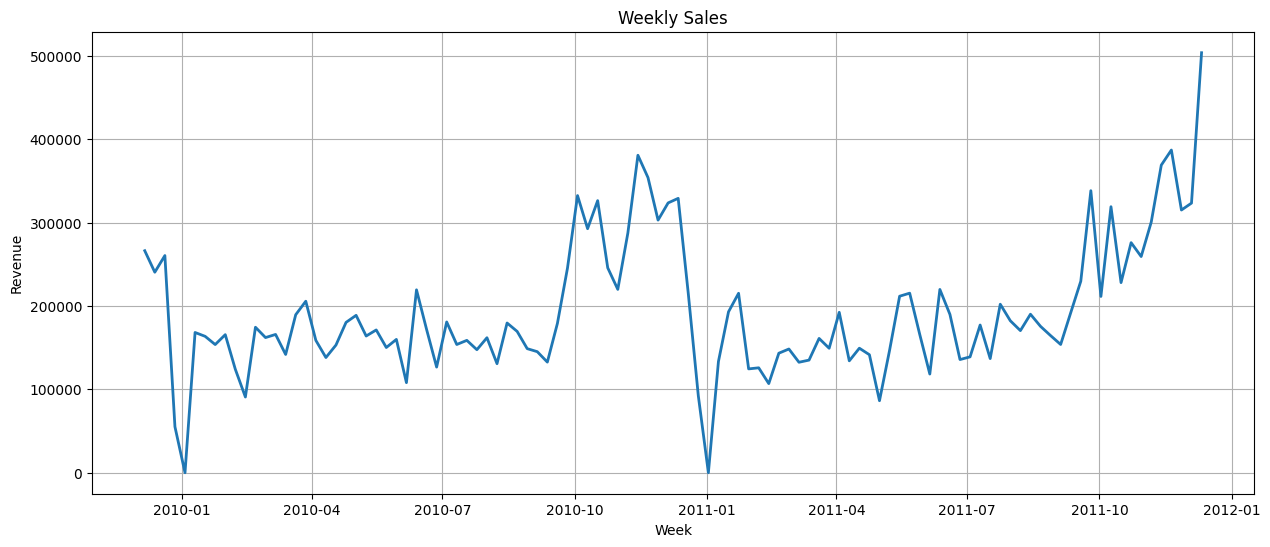

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["InvoiceDate"],
    weekly_sales["TotalSales"],
    linewidth=2
)

plt.title("Weekly Sales")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [37]:
weekly_sales.shape

(106, 2)

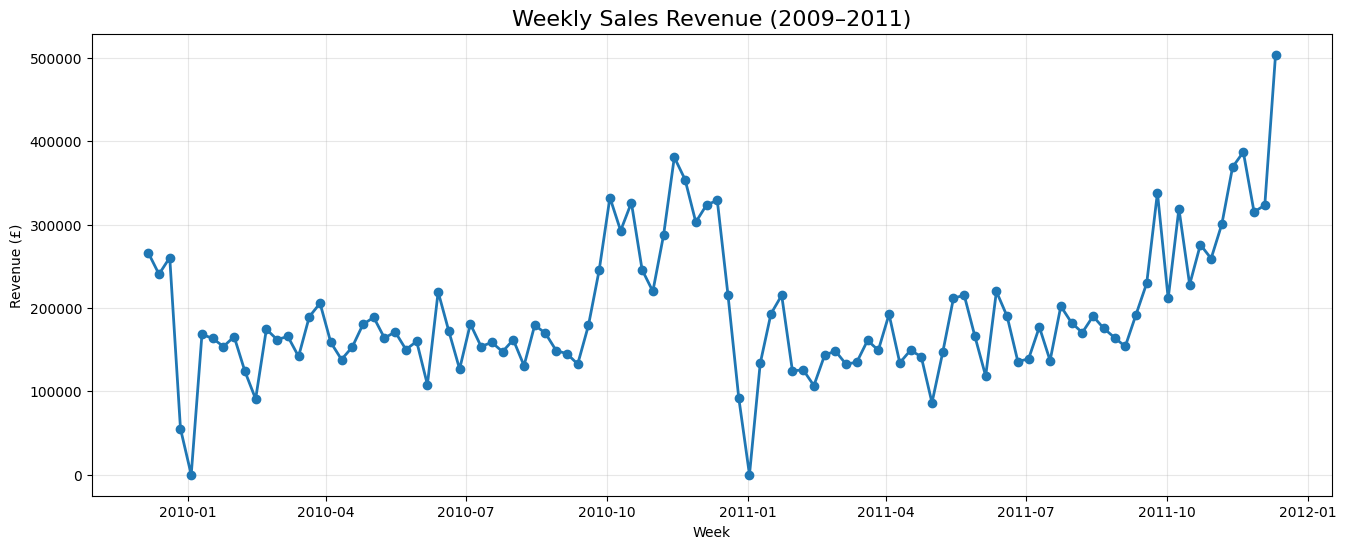

In [38]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["InvoiceDate"],
    weekly_sales["TotalSales"],
    marker="o",
    linewidth=2
)

plt.title("Weekly Sales Revenue (2009–2011)", fontsize=16)
plt.xlabel("Week")
plt.ylabel("Revenue (£)")
plt.grid(alpha=0.3)

plt.show()

In [39]:
!pip install prophet

In [40]:
forecast_df = weekly_sales.rename(
    columns={
        "InvoiceDate": "ds",
        "TotalSales": "y"
    }
)

forecast_df.head()

,ds,y
0,2009-12-06,266304.65
1,2009-12-13,240516.41
2,2009-12-20,260473.31
3,2009-12-27,55189.58
4,2010-01-03,0.00


In [41]:
from prophet import Prophet

model = Prophet()

model.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [42]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(forecast_df)

In [43]:
# Generate dates for the next 12 weeks
future = model.make_future_dataframe(
    periods=12,
    freq='W'
)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-06,177276.895523,283842.870650,380662.413122,177276.895523,177276.895523,155562.366863,155562.366863,155562.366863,155562.366863,155562.366863,155562.366863,0.0,0.0,0.0,332839.262386
1,2009-12-13,177537.965331,242162.304820,333542.006600,177537.965331,177537.965331,109572.712105,109572.712105,109572.712105,109572.712105,109572.712105,109572.712105,0.0,0.0,0.0,287110.677435
2,2009-12-20,177799.035138,141690.997009,232911.695821,177799.035138,177799.035138,9683.821277,9683.821277,9683.821277,9683.821277,9683.821277,9683.821277,0.0,0.0,0.0,187482.856415
3,2009-12-27,178060.104945,38051.889479,132316.172579,178060.104945,178060.104945,-92196.857046,-92196.857046,-92196.857046,-92196.857046,-92196.857046,-92196.857046,0.0,0.0,0.0,85863.247900
4,2010-01-03,178321.174746,4023.435344,97345.847562,178321.174746,178321.174746,-127847.335351,-127847.335351,-127847.335351,-127847.335351,-127847.335351,-127847.335351,0.0,0.0,0.0,50473.839396


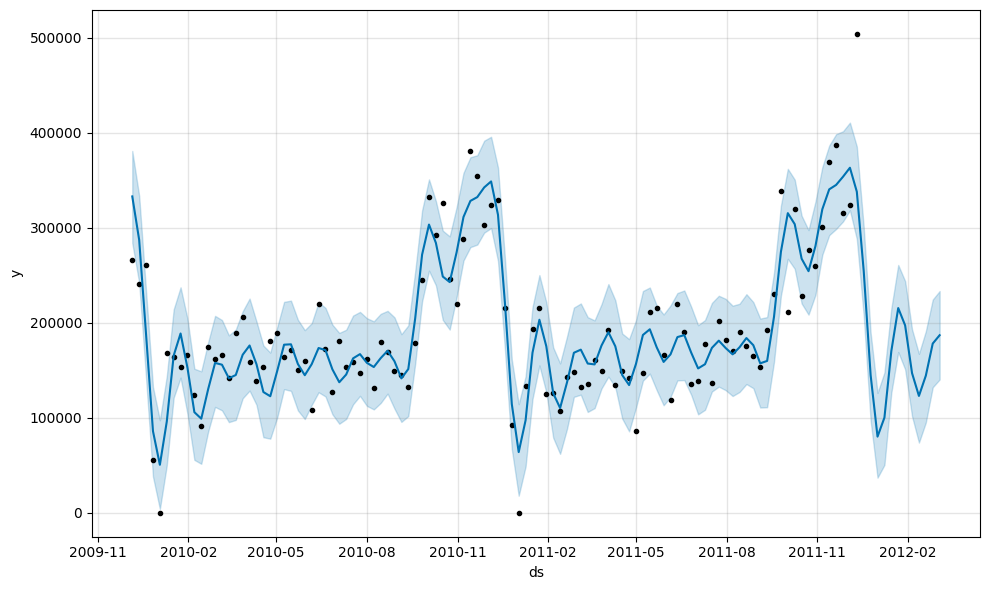

In [44]:
fig = model.plot(forecast)

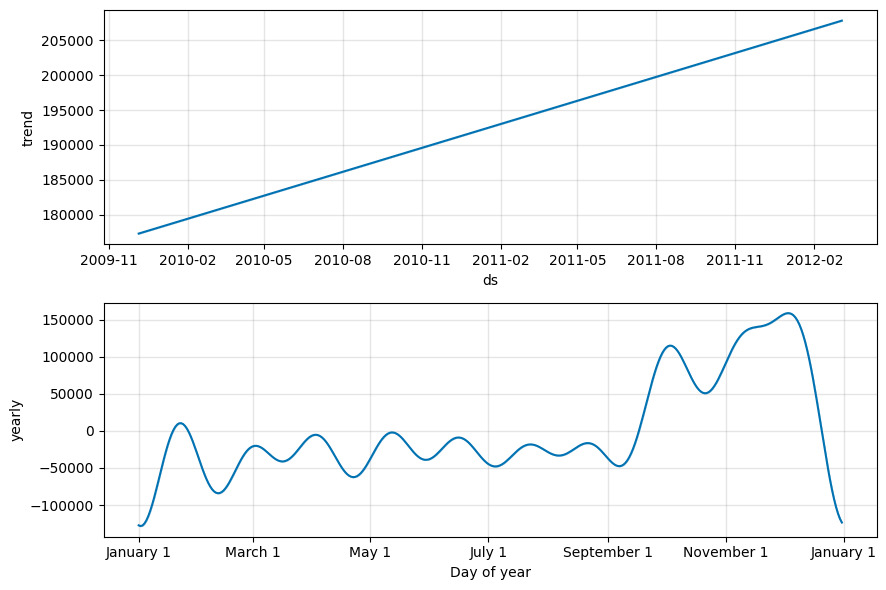

In [45]:
fig2 = model.plot_components(forecast)

In [46]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2
)

In [47]:
results = forecast_df.merge(
    forecast[['ds','yhat']],
    on='ds',
    how='left'
)

results.head()

,ds,y,yhat
0,2009-12-06,266304.65,332839.262386
1,2009-12-13,240516.41,287110.677435
2,2009-12-20,260473.31,187482.856415
3,2009-12-27,55189.58,85863.247900
4,2010-01-03,0.00,50473.839396


In [48]:
results['Deviation'] = (
    abs(results['y'] - results['yhat'])
    / results['yhat']
) * 100

In [49]:
results['Anomaly'] = results['Deviation'] > 10

In [50]:
print(results['Anomaly'].value_counts())

Anomaly
True     57
False    49
Name: count, dtype: int64


In [51]:
results[results['Anomaly']].head(20)

,ds,y,yhat,Deviation,Anomaly
0,2009-12-06,266304.65,332839.262386,19.990013,True
1,2009-12-13,240516.41,287110.677435,16.228678,True
2,2009-12-20,260473.31,187482.856415,38.931802,True
3,2009-12-27,55189.58,85863.247900,35.723862,True
4,2010-01-03,0.00,50473.839396,100.000000,True
...,...,...,...,...,...
25,2010-05-30,159908.38,144738.008673,10.481263,True
26,2010-06-06,108024.30,156331.344092,30.900421,True
27,2010-06-13,219386.54,173353.113887,26.554715,True
29,2010-06-27,126710.01,150934.156144,16.049479,True


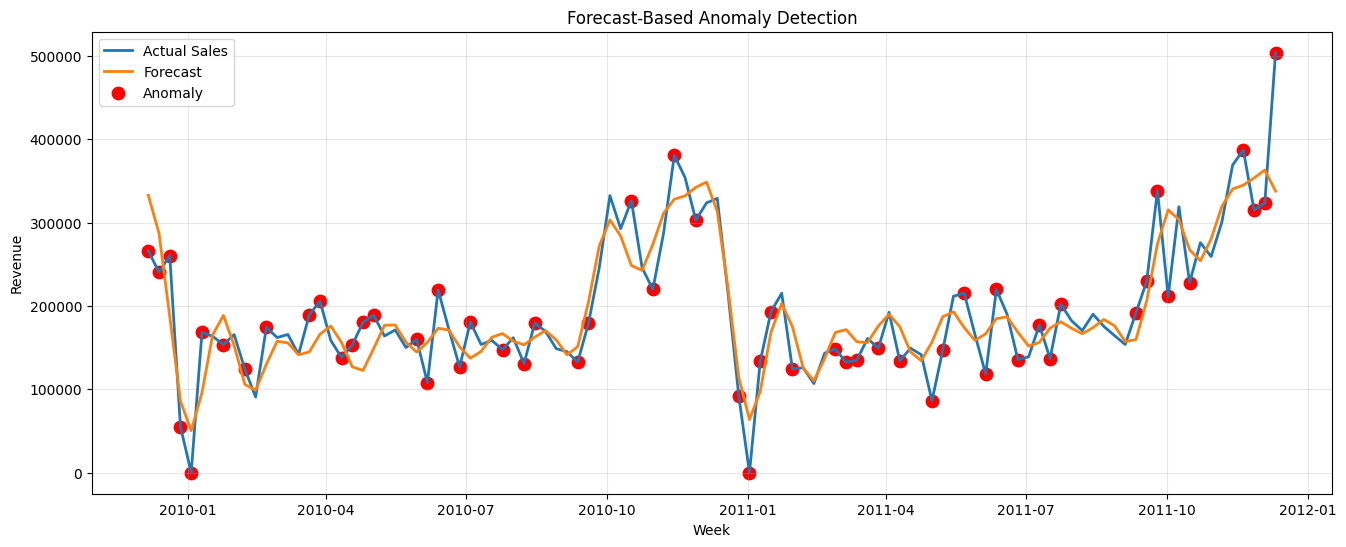

In [52]:
plt.figure(figsize=(16,6))

plt.plot(
    results['ds'],
    results['y'],
    label='Actual Sales',
    linewidth=2
)

plt.plot(
    results['ds'],
    results['yhat'],
    label='Forecast',
    linewidth=2
)

plt.scatter(
    results.loc[results['Anomaly'], 'ds'],
    results.loc[results['Anomaly'], 'y'],
    color='red',
    s=80,
    label='Anomaly'
)

plt.title("Forecast-Based Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [53]:
results = forecast_df.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds'
)

results['Anomaly'] = (
    (results['y'] > results['yhat_upper']) |
    (results['y'] < results['yhat_lower'])
)

In [54]:
print(results['Anomaly'].value_counts())

Anomaly
False    89
True     17
Name: count, dtype: int64


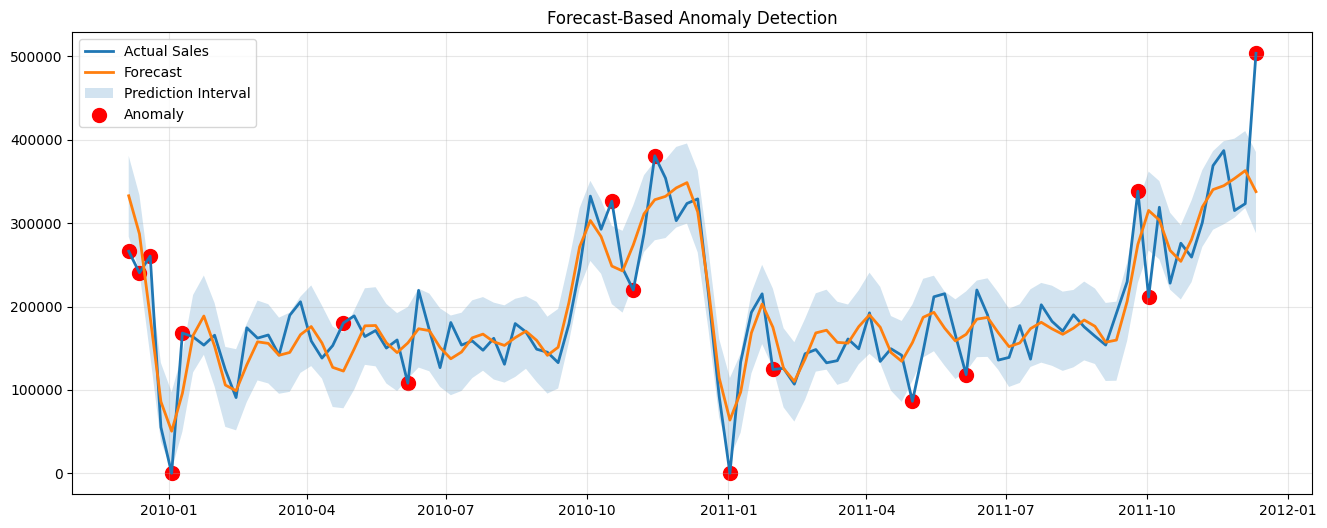

In [55]:
plt.figure(figsize=(16,6))

plt.plot(results['ds'], results['y'], label='Actual Sales', linewidth=2)
plt.plot(results['ds'], results['yhat'], label='Forecast', linewidth=2)

plt.fill_between(
    results['ds'],
    results['yhat_lower'],
    results['yhat_upper'],
    alpha=0.2,
    label='Prediction Interval'
)

plt.scatter(
    results.loc[results['Anomaly'], 'ds'],
    results.loc[results['Anomaly'], 'y'],
    color='red',
    s=100,
    label='Anomaly'
)

plt.legend()
plt.grid(alpha=0.3)
plt.title("Forecast-Based Anomaly Detection")
plt.show()

In [56]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

In [57]:
model.fit(forecast_df)

future = model.make_future_dataframe(periods=12, freq='W')

forecast = model.predict(future)

In [58]:
results = forecast_df.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds'
)

In [59]:
results["AnomalyType"] = "Normal"

results.loc[
    results["y"] > results["yhat_upper"],
    "AnomalyType"
] = "High Sales"

results.loc[
    results["y"] < results["yhat_lower"],
    "AnomalyType"
] = "Low Sales"

In [60]:
results["AnomalyType"].value_counts()

,count
AnomalyType,
Normal,101
High Sales,4
Low Sales,1


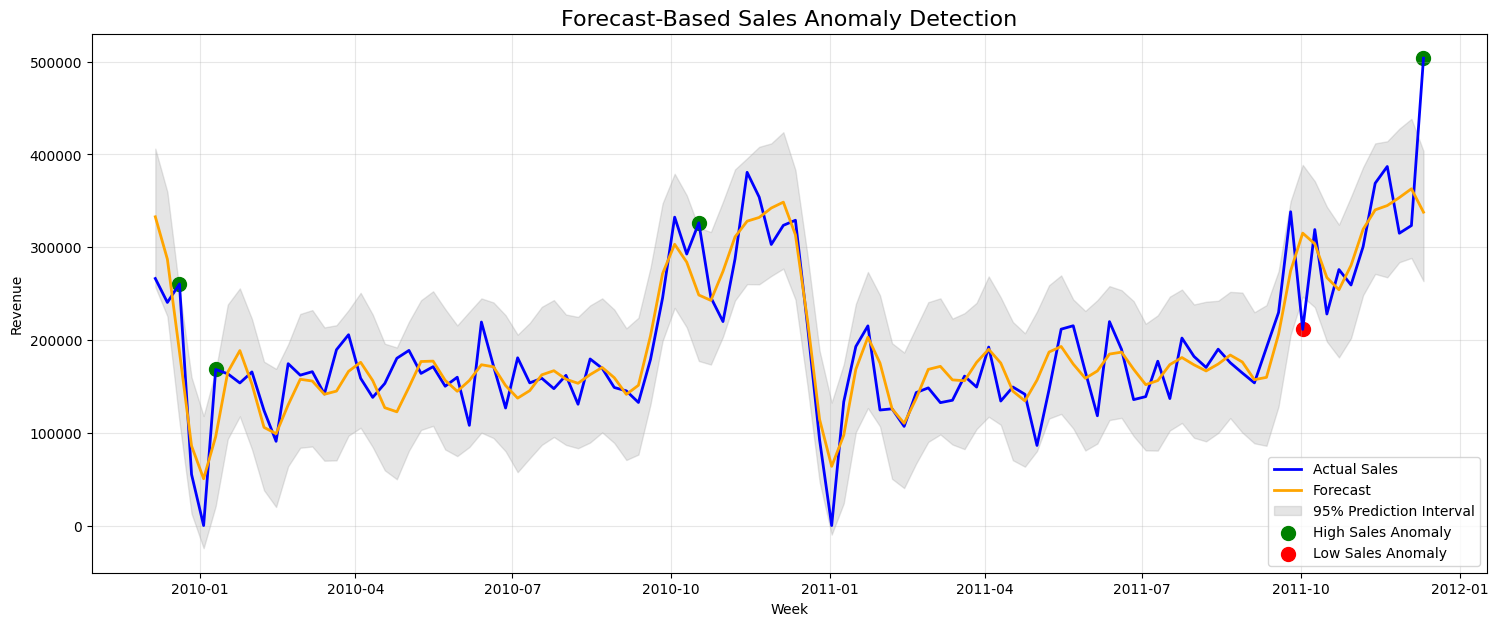

In [61]:
plt.figure(figsize=(18,7))

# Actual Sales
plt.plot(
    results["ds"],
    results["y"],
    color="blue",
    linewidth=2,
    label="Actual Sales"
)

# Forecast
plt.plot(
    results["ds"],
    results["yhat"],
    color="orange",
    linewidth=2,
    label="Forecast"
)

# Prediction Interval
plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2,
    color="gray",
    label="95% Prediction Interval"
)

# High anomalies
high = results[results["AnomalyType"] == "High Sales"]

plt.scatter(
    high["ds"],
    high["y"],
    color="green",
    s=100,
    label="High Sales Anomaly"
)

# Low anomalies
low = results[results["AnomalyType"] == "Low Sales"]

plt.scatter(
    low["ds"],
    low["y"],
    color="red",
    s=100,
    label="Low Sales Anomaly"
)

plt.title("Forecast-Based Sales Anomaly Detection", fontsize=16)

plt.xlabel("Week")
plt.ylabel("Revenue")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [62]:
results[
    results["AnomalyType"] != "Normal"
][
    ["ds", "y", "yhat", "AnomalyType"]
]

,ds,y,yhat,AnomalyType
2,2009-12-20,260473.310,187482.856415,High Sales
5,2010-01-10,168228.580,95918.630852,High Sales
45,2010-10-17,326358.220,248535.186128,High Sales
95,2011-10-02,211446.801,315233.052795,Low Sales
105,2011-12-11,503785.750,337814.271320,High Sales


In [63]:
forecast.tail(12)[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

,ds,yhat,yhat_lower,yhat_upper
106,2011-12-18,254304.033774,179252.568579,325322.986606
107,2011-12-25,144837.000476,72571.105639,221600.901937
108,2012-01-01,80120.199032,8076.529706,152701.239010
109,2012-01-08,100111.638258,29098.854979,172069.121600
110,2012-01-15,170151.926838,105751.688227,241857.777609
...,...,...,...,...
113,2012-02-05,146973.989578,74440.192180,218429.077301
114,2012-02-12,122947.247628,51468.408706,194093.585698
115,2012-02-19,144254.726705,74115.542500,216128.223092
116,2012-02-26,178027.191139,103345.781363,247795.247145


In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(results["y"], results["yhat"])
rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MAE : 27,549.08
RMSE: 36,860.19


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(results["y"], results["yhat"])
rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

mape = np.mean(
    np.abs((results["y"] - results["yhat"]) / results["y"])
) * 100

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 27,549.08
RMSE : 36,860.19
MAPE : inf%


In [66]:
print("Average Weekly Sales:", weekly_sales["TotalSales"].mean())

Average Weekly Sales: 193172.26837735847


In [67]:
mape = (
    abs(results["y"] - results["yhat"]) /
    results["y"]
).mean() * 100

print(f"MAPE = {mape:.2f}%")

MAPE = inf%


In [68]:
# Remove weeks where actual sales are zero
results_nonzero = results[results["y"] > 0]

mape = (
    abs(results_nonzero["y"] - results_nonzero["yhat"])
    / results_nonzero["y"]
).mean() * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 14.55%


In [69]:
from sklearn.metrics import mean_absolute_percentage_error

results_nonzero = results[results["y"] > 0]

mape = mean_absolute_percentage_error(
    results_nonzero["y"],
    results_nonzero["yhat"]
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 14.55%


In [71]:
weekly_sales[weekly_sales["TotalSales"] == 0]

,InvoiceDate,TotalSales
4,2010-01-03,0.0
56,2011-01-02,0.0


In [73]:
# Create weekly period for each transaction
clean_df["Week"] = (
    clean_df["InvoiceDate"]
    .dt.to_period("W")
    .apply(lambda r: r.end_time.normalize())
)

clean_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalSales,Week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12-06
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-06
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-06
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12-06
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12-06


In [75]:
def analyze_anomaly(week):

    week_data = clean_df[
        clean_df["Week"] == week
    ]

    print("="*70)
    print(f"Week Ending : {week.date()}")
    print("="*70)

    print("\nTop Products")

    print(
        week_data.groupby("Description")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\nTop Customers")

    print(
        week_data.groupby("Customer ID")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\nTop Countries")

    print(
        week_data.groupby("Country")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
    )

In [76]:
for week in anomalies["ds"]:
    analyze_anomaly(week)

NameError: name 'anomalies' is not defined

In [77]:
results.head()

,ds,y,yhat,yhat_lower,yhat_upper,AnomalyType
0,2009-12-06,266304.65,332839.262386,257214.876657,406332.226555,Normal
1,2009-12-13,240516.41,287110.677435,225579.761837,359618.390492,Normal
2,2009-12-20,260473.31,187482.856415,112046.117319,253651.147285,High Sales
3,2009-12-27,55189.58,85863.247900,12959.229749,159819.890321,Normal
4,2010-01-03,0.00,50473.839396,-24438.018943,118055.137206,Normal


In [78]:
anomalies = results[
    results["AnomalyType"] != "Normal"
].copy()

print(anomalies[["ds", "y", "AnomalyType"]])

            ds           y AnomalyType
2   2009-12-20  260473.310  High Sales
5   2010-01-10  168228.580  High Sales
45  2010-10-17  326358.220  High Sales
95  2011-10-02  211446.801   Low Sales
105 2011-12-11  503785.750  High Sales


In [79]:
print(clean_df[["InvoiceDate", "Week"]].head())

          InvoiceDate       Week
0 2009-12-01 07:45:00 2009-12-06
1 2009-12-01 07:45:00 2009-12-06
2 2009-12-01 07:45:00 2009-12-06
3 2009-12-01 07:45:00 2009-12-06
4 2009-12-01 07:45:00 2009-12-06


In [80]:
for week in anomalies["ds"]:
    analyze_anomaly(week)

Week Ending : 2009-12-20

Top Products
Description
DOTCOM POSTAGE                        7065.05
WHITE HANGING HEART T-LIGHT HOLDER    3633.23
SCOTTIE DOG HOT WATER BOTTLE          2968.36
JUMBO BAG RED WHITE SPOTTY            2354.50
TEA TIME CAKE STAND IN GIFT BOX       2277.05
RETRO SPOT CAKE STAND                 2266.20
ASSORTED COLOUR BIRD ORNAMENT         2230.06
HOT WATER BOTTLE TEA AND SYMPATHY     2162.35
PAPER CHAIN KIT 50'S CHRISTMAS        2011.23
 WHITE CHERRY LIGHTS                  1961.14
Name: TotalSales, dtype: float64

Top Customers
Customer ID
13694.0    16291.78
14646.0     8881.28
18102.0     6156.46
17511.0     5259.17
14911.0     3638.69
15061.0     3490.00
15311.0     3423.08
15498.0     3326.72
14063.0     3176.60
14527.0     2804.57
Name: TotalSales, dtype: float64

Top Countries
Country
United Kingdom    232743.33
Netherlands         8881.28
EIRE                7164.22
Germany             4459.38
Cyprus              2780.99
                    ...    
Franc

In [81]:
print(results.columns)

Index(['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'AnomalyType'], dtype='object')


In [82]:
def analyze_anomaly_summary(week):

    week_data = clean_df[clean_df["Week"] == week]

    actual = results.loc[results["ds"] == week, "y"].iloc[0]
    forecast = results.loc[results["ds"] == week, "yhat"].iloc[0]
    anomaly = results.loc[results["ds"] == week, "AnomalyType"].iloc[0]

    deviation = ((actual - forecast) / forecast) * 100

    top_product = (
        week_data.groupby("Description")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
        .head(1)
    )

    top_customer = (
        week_data.groupby("Customer ID")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
        .head(1)
    )

    top_country = (
        week_data.groupby("Country")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
        .head(1)
    )

    print("=" * 80)
    print(f"ANOMALY REPORT : {week.date()}")
    print("=" * 80)

    print(f"Type              : {anomaly}")
    print(f"Actual Sales      : £{actual:,.2f}")
    print(f"Forecast Sales    : £{forecast:,.2f}")
    print(f"Deviation         : {deviation:.1f}%")

    print("\nTop Product")

    print(top_product)

    print("\nTop Customer")

    print(top_customer)

    print("\nTop Country")

    print(top_country)

    print("\nAI Business Summary")

    print(
        f"""
• {anomaly} detected.

• Weekly sales differed from forecast by {deviation:.1f}%.

• Highest revenue came from '{top_product.index[0]}'.

• Largest customer contribution came from Customer {int(top_customer.index[0])}.

• Most sales originated from {top_country.index[0]}.

• This anomaly should be investigated by business teams.
"""
    )

In [83]:
for week in anomalies["ds"]:
    analyze_anomaly_summary(week)

ANOMALY REPORT : 2009-12-20
Type              : High Sales
Actual Sales      : £260,473.31
Forecast Sales    : £187,482.86
Deviation         : 38.9%

Top Product
Description
DOTCOM POSTAGE    7065.05
Name: TotalSales, dtype: float64

Top Customer
Customer ID
13694.0    16291.78
Name: TotalSales, dtype: float64

Top Country
Country
United Kingdom    232743.33
Name: TotalSales, dtype: float64

AI Business Summary

• High Sales detected.

• Weekly sales differed from forecast by 38.9%.

• Highest revenue came from 'DOTCOM POSTAGE'.

• Largest customer contribution came from Customer 13694.

• Most sales originated from United Kingdom.

• This anomaly should be investigated by business teams.

ANOMALY REPORT : 2010-01-10
Type              : High Sales
Actual Sales      : £168,228.58
Forecast Sales    : £95,918.63
Deviation         : 75.4%

Top Product
Description
WHITE HANGING HEART T-LIGHT HOLDER    4628.75
Name: TotalSales, dtype: float64

Top Customer
Customer ID
14156.0    44051.6
Name

In [84]:
exclude_products = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual",
    "M",
    "BANK CHARGES",
    "ADJUST",
    "ADJUSTMENT",
    "CARRIAGE",
    "SAMPLES"
]

In [85]:
product_data = week_data[
    ~week_data["Description"].isin(exclude_products)
]

NameError: name 'week_data' is not defined

In [86]:
exclude_products = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual",
    "M",
    "BANK CHARGES",
    "BANK CHARGES ",
    "ADJUST",
    "ADJUSTMENT",
    "CARRIAGE",
    "SAMPLES"
]

In [87]:
def analyze_anomaly_summary(week):

    # Filter data for the anomaly week
    week_data = clean_df[clean_df["Week"] == week].copy()

    # Remove non-product entries
    product_data = week_data[
        ~week_data["Description"].isin(exclude_products)
    ]

    # Retrieve forecast information
    row = results[results["ds"] == week].iloc[0]

    actual = row["y"]
    forecast = row["yhat"]
    anomaly = row["AnomalyType"]

    deviation = ((actual - forecast) / forecast) * 100

    # Top Product
    top_product = (
        product_data.groupby("Description")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
    )

    # Top Customer
    top_customer = (
        week_data.groupby("Customer ID")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
    )

    # Top Country
    top_country = (
        week_data.groupby("Country")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
    )

    product_name = top_product.index[0]
    product_sales = top_product.iloc[0]
    contribution = product_sales / actual * 100

    customer = int(top_customer.index[0])
    customer_sales = top_customer.iloc[0]

    country = top_country.index[0]

    print("="*80)
    print(f"ANOMALY REPORT : {week.date()}")
    print("="*80)

    print(f"Type              : {anomaly}")
    print(f"Actual Sales      : £{actual:,.2f}")
    print(f"Forecast Sales    : £{forecast:,.2f}")
    print(f"Deviation         : {deviation:.1f}%")

    print("\nTop Product")
    print(f"{product_name}")
    print(f"Revenue: £{product_sales:,.2f}")
    print(f"Contribution: {contribution:.1f}%")

    print("\nTop Customer")
    print(f"Customer {customer}")
    print(f"Revenue: £{customer_sales:,.2f}")

    print("\nTop Country")
    print(country)

    print("\nAI Business Insight")
    print("-"*80)

    if anomaly == "High Sales":
        print(
            f"Weekly sales exceeded the forecast by {deviation:.1f}%.\n"
            f"The highest-selling product was '{product_name}', "
            f"contributing {contribution:.1f}% of weekly revenue.\n"
            f"The largest customer contribution came from Customer {customer}.\n"
            f"Most sales originated from {country}.\n"
            f"This pattern suggests unusually strong customer demand or a bulk purchase."
        )
    else:
        print(
            f"Weekly sales were {abs(deviation):.1f}% below forecast.\n"
            f"No single product dominated sales, suggesting a broad decline rather than one missing order.\n"
            f"Most revenue still originated from {country}.\n"
            f"This anomaly may indicate weaker demand, inventory issues, or operational disruptions."
        )

    print("="*80)

In [88]:
for week in anomalies["ds"]:
    analyze_anomaly_summary(week)

ANOMALY REPORT : 2009-12-20
Type              : High Sales
Actual Sales      : £260,473.31
Forecast Sales    : £187,482.86
Deviation         : 38.9%

Top Product
WHITE HANGING HEART T-LIGHT HOLDER
Revenue: £3,633.23
Contribution: 1.4%

Top Customer
Customer 13694
Revenue: £16,291.78

Top Country
United Kingdom

AI Business Insight
--------------------------------------------------------------------------------
Weekly sales exceeded the forecast by 38.9%.
The highest-selling product was 'WHITE HANGING HEART T-LIGHT HOLDER', contributing 1.4% of weekly revenue.
The largest customer contribution came from Customer 13694.
Most sales originated from United Kingdom.
This pattern suggests unusually strong customer demand or a bulk purchase.
ANOMALY REPORT : 2010-01-10
Type              : High Sales
Actual Sales      : £168,228.58
Forecast Sales    : £95,918.63
Deviation         : 75.4%

Top Product
WHITE HANGING HEART T-LIGHT HOLDER
Revenue: £4,628.75
Contribution: 2.8%

Top Customer
Customer

In [89]:
previous_week = week - pd.Timedelta(weeks=1)

previous_data = clean_df[
    clean_df["Week"] == previous_week
]

In [90]:
current_products = (
    product_data.groupby("Description")["TotalSales"]
    .sum()
)

previous_products = (
    previous_data.groupby("Description")["TotalSales"]
    .sum()
)

NameError: name 'product_data' is not defined

In [91]:
def root_cause_analysis(week):

    # Current week
    current_week = clean_df[clean_df["Week"] == week].copy()

    # Previous week
    previous_week = week - pd.Timedelta(weeks=1)

    previous = clean_df[
        clean_df["Week"] == previous_week
    ].copy()

    # Remove non-business products
    exclude_products = [
        "DOTCOM POSTAGE",
        "POSTAGE",
        "Manual",
        "M",
        "BANK CHARGES",
        "ADJUST",
        "ADJUSTMENT",
        "CARRIAGE",
        "SAMPLES"
    ]

    current_week = current_week[
        ~current_week["Description"].isin(exclude_products)
    ]

    previous = previous[
        ~previous["Description"].isin(exclude_products)
    ]

    # Aggregate sales
    current_products = (
        current_week
        .groupby("Description")["TotalSales"]
        .sum()
    )

    previous_products = (
        previous
        .groupby("Description")["TotalSales"]
        .sum()
    )

    # Compare
    comparison = pd.concat(
        [previous_products, current_products],
        axis=1
    ).fillna(0)

    comparison.columns = [
        "Previous Week",
        "Current Week"
    ]

    comparison["Change"] = (
        comparison["Current Week"]
        - comparison["Previous Week"]
    )

    comparison = comparison.sort_values(
        "Change",
        ascending=False
    )

    print("="*80)
    print("TOP GROWTH DRIVERS")
    print("="*80)

    print(comparison.head(10))

    return comparison

In [92]:
comparison = root_cause_analysis(
    pd.Timestamp("2011-12-11")
)

TOP GROWTH DRIVERS
                                 Previous Week  Current Week     Change
Description                                                            
PAPER CRAFT , LITTLE BIRDIE               0.00     168469.60  168469.60
BLACK RECORD COVER FRAME                735.80       5337.29    4601.49
METAL SIGN TAKE IT OR LEAVE IT           82.49       3955.40    3872.91
WALL ART KEEP CALM                      139.75       2950.55    2810.80
SWEETHEART BIRD HOUSE                    87.15       2149.68    2062.53
ANTIQUE HEART SHELF UNIT                133.19       2152.33    2019.14
ALARM CLOCK BAKELIKE RED               1201.08       3217.39    2016.31
REGENCY CAKESTAND 3 TIER               3254.04       4871.85    1617.81
NATURAL SLATE HEART CHALKBOARD          752.78       2226.46    1473.68
LANDMARK FRAME CAMDEN TOWN              137.46       1498.46    1361.00


In [93]:
for week in anomalies["ds"]:
    print("\n")
    print("="*100)
    print(week.date())
    print("="*100)

    root_cause_analysis(week)



2009-12-20
TOP GROWTH DRIVERS
                                    Previous Week  Current Week   Change
Description                                                             
DOORMAT HEARTS                             397.97       1616.22  1218.25
JUMBO BAG CHARLIE AND LOLA TOYS            294.39       1428.00  1133.61
BLUE 3 PIECE MINI DOTS CUTLERY SET         262.78       1310.63  1047.85
TEA TIME CAKE STAND IN GIFT BOX           1258.00       2277.05  1019.05
RETRO SPOT CAKE STAND                     1459.60       2266.20   806.60
DOOR MAT FAIRY CAKE                        602.22       1401.59   799.37
 WHITE CHERRY LIGHTS                      1213.62       1961.14   747.52
SPOTTY  HOME SWEET HOME DOORMAT            311.10       1039.50   728.40
RED WOOLLY HOTTIE WHITE HEART.             720.55       1446.95   726.40
DOOR MAT BIRD ON THE WIRE                  113.87        828.48   714.61


2010-01-10
TOP GROWTH DRIVERS
                                    Previous Week  Current W

In [94]:
reports = []

for week in anomalies["ds"]:

    report = generate_anomaly_report(week)

    reports.append(report)

reports_df = pd.DataFrame(reports)

reports_df

NameError: name 'generate_anomaly_report' is not defined

In [95]:
def generate_anomaly_report(week):

    # ----------------------------
    # Current & Previous Week Data
    # ----------------------------
    current_week = clean_df[clean_df["Week"] == week].copy()
    previous_week = clean_df[
        clean_df["Week"] == (week - pd.Timedelta(weeks=1))
    ].copy()

    # Remove non-business items
    exclude_products = [
        "DOTCOM POSTAGE",
        "POSTAGE",
        "Manual",
        "M",
        "BANK CHARGES",
        "ADJUST",
        "ADJUSTMENT",
        "CARRIAGE",
        "SAMPLES"
    ]

    current_week = current_week[
        ~current_week["Description"].isin(exclude_products)
    ]

    previous_week = previous_week[
        ~previous_week["Description"].isin(exclude_products)
    ]

    # ----------------------------
    # Forecast Information
    # ----------------------------
    row = results[results["ds"] == week].iloc[0]

    actual = row["y"]
    forecast = row["yhat"]
    anomaly = row["AnomalyType"]

    deviation = ((actual - forecast) / forecast) * 100

    # ----------------------------
    # Top Product
    # ----------------------------
    top_product = (
        current_week.groupby("Description")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
    )

    product_name = top_product.index[0]
    product_sales = top_product.iloc[0]

    # ----------------------------
    # Top Customer
    # ----------------------------
    top_customer = (
        current_week.groupby("Customer ID")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
    )

    customer_id = int(top_customer.index[0])
    customer_sales = top_customer.iloc[0]

    # ----------------------------
    # Top Country
    # ----------------------------
    top_country = (
        current_week.groupby("Country")["TotalSales"]
        .sum()
        .sort_values(ascending=False)
    )

    country = top_country.index[0]

    # ----------------------------
    # Root Cause Analysis
    # ----------------------------
    current_products = (
        current_week.groupby("Description")["TotalSales"]
        .sum()
    )

    previous_products = (
        previous_week.groupby("Description")["TotalSales"]
        .sum()
    )

    comparison = pd.concat(
        [previous_products, current_products],
        axis=1
    ).fillna(0)

    comparison.columns = [
        "Previous Week",
        "Current Week"
    ]

    comparison["Change"] = (
        comparison["Current Week"]
        - comparison["Previous Week"]
    )

    comparison = comparison.sort_values(
        "Change",
        ascending=False
    )

    driver = comparison.index[0]
    driver_change = comparison.iloc[0]["Change"]

    # ----------------------------
    # Business Recommendation
    # ----------------------------
    if anomaly == "High Sales":
        recommendation = (
            "Review inventory levels, validate whether the increase is "
            "due to seasonal demand or a bulk customer order, and "
            "prepare replenishment if demand is expected to continue."
        )
    else:
        recommendation = (
            "Investigate inventory availability, operational issues, "
            "pricing, promotions, or changes in customer demand."
        )

    # ----------------------------
    # Return Report
    # ----------------------------
    return {
        "Week": week.date(),
        "Type": anomaly,
        "Actual Sales": round(actual, 2),
        "Forecast Sales": round(forecast, 2),
        "Deviation %": round(deviation, 1),
        "Top Product": product_name,
        "Top Customer": customer_id,
        "Top Country": country,
        "Root Cause Driver": driver,
        "Driver Increase": round(driver_change, 2),
        "Recommendation": recommendation
    }

In [96]:
reports = []

for week in anomalies["ds"]:
    reports.append(generate_anomaly_report(week))

reports_df = pd.DataFrame(reports)

reports_df

,Week,Type,Actual Sales,Forecast Sales,Deviation %,Top Product,Top Customer,Top Country,Root Cause Driver,Driver Increase,Recommendation
0,2009-12-20,High Sales,260473.31,187482.86,38.9,WHITE HANGING HEART T-LIGHT HOLDER,13694,United Kingdom,DOORMAT HEARTS,1218.25,"Review inventory levels, validate whether the ..."
1,2010-01-10,High Sales,168228.58,95918.63,75.4,WHITE HANGING HEART T-LIGHT HOLDER,14156,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,4628.75,"Review inventory levels, validate whether the ..."
2,2010-10-17,High Sales,326358.22,248535.19,31.3,REGENCY CAKESTAND 3 TIER,18102,United Kingdom,"MIRROR, ARCHED GEORGIAN",3884.00,"Review inventory levels, validate whether the ..."
3,2011-10-02,Low Sales,211446.80,315233.05,-32.9,DOORMAT KEEP CALM AND COME IN,14156,United Kingdom,DOORMAT KEEP CALM AND COME IN,4473.63,"Investigate inventory availability, operationa..."
4,2011-12-11,High Sales,503785.75,337814.27,49.1,"PAPER CRAFT , LITTLE BIRDIE",16446,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",168469.60,"Review inventory levels, validate whether the ..."


In [97]:
reports_df[
    [
        "Week",
        "Type",
        "Deviation %",
        "Top Product",
        "Root Cause Driver",
        "Recommendation"
    ]
]

,Week,Type,Deviation %,Top Product,Root Cause Driver,Recommendation
0,2009-12-20,High Sales,38.9,WHITE HANGING HEART T-LIGHT HOLDER,DOORMAT HEARTS,"Review inventory levels, validate whether the ..."
1,2010-01-10,High Sales,75.4,WHITE HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,"Review inventory levels, validate whether the ..."
2,2010-10-17,High Sales,31.3,REGENCY CAKESTAND 3 TIER,"MIRROR, ARCHED GEORGIAN","Review inventory levels, validate whether the ..."
3,2011-10-02,Low Sales,-32.9,DOORMAT KEEP CALM AND COME IN,DOORMAT KEEP CALM AND COME IN,"Investigate inventory availability, operationa..."
4,2011-12-11,High Sales,49.1,"PAPER CRAFT , LITTLE BIRDIE","PAPER CRAFT , LITTLE BIRDIE","Review inventory levels, validate whether the ..."


In [98]:
reports_df.to_excel(
    "Anomaly_Report.xlsx",
    index=False
)

In [99]:
summary = pd.DataFrame({

    "Metric":[
        "Original Transactions",
        "Clean Transactions",
        "Weekly Observations",
        "Forecast Model",
        "MAE",
        "RMSE",
        "Detected Anomalies",
        "High Sales",
        "Low Sales"
    ],

    "Value":[
        "1,067,371",
        "1,007,913",
        "106",
        "Prophet",
        "27,549",
        "36,860",
        "5",
        "4",
        "1"
    ]
})

summary

,Metric,Value
0,Original Transactions,"1,067,371"
1,Clean Transactions,"1,007,913"
2,Weekly Observations,106
3,Forecast Model,Prophet
4,MAE,"27,549"
5,RMSE,"36,860"
6,Detected Anomalies,5
7,High Sales,4
8,Low Sales,1
